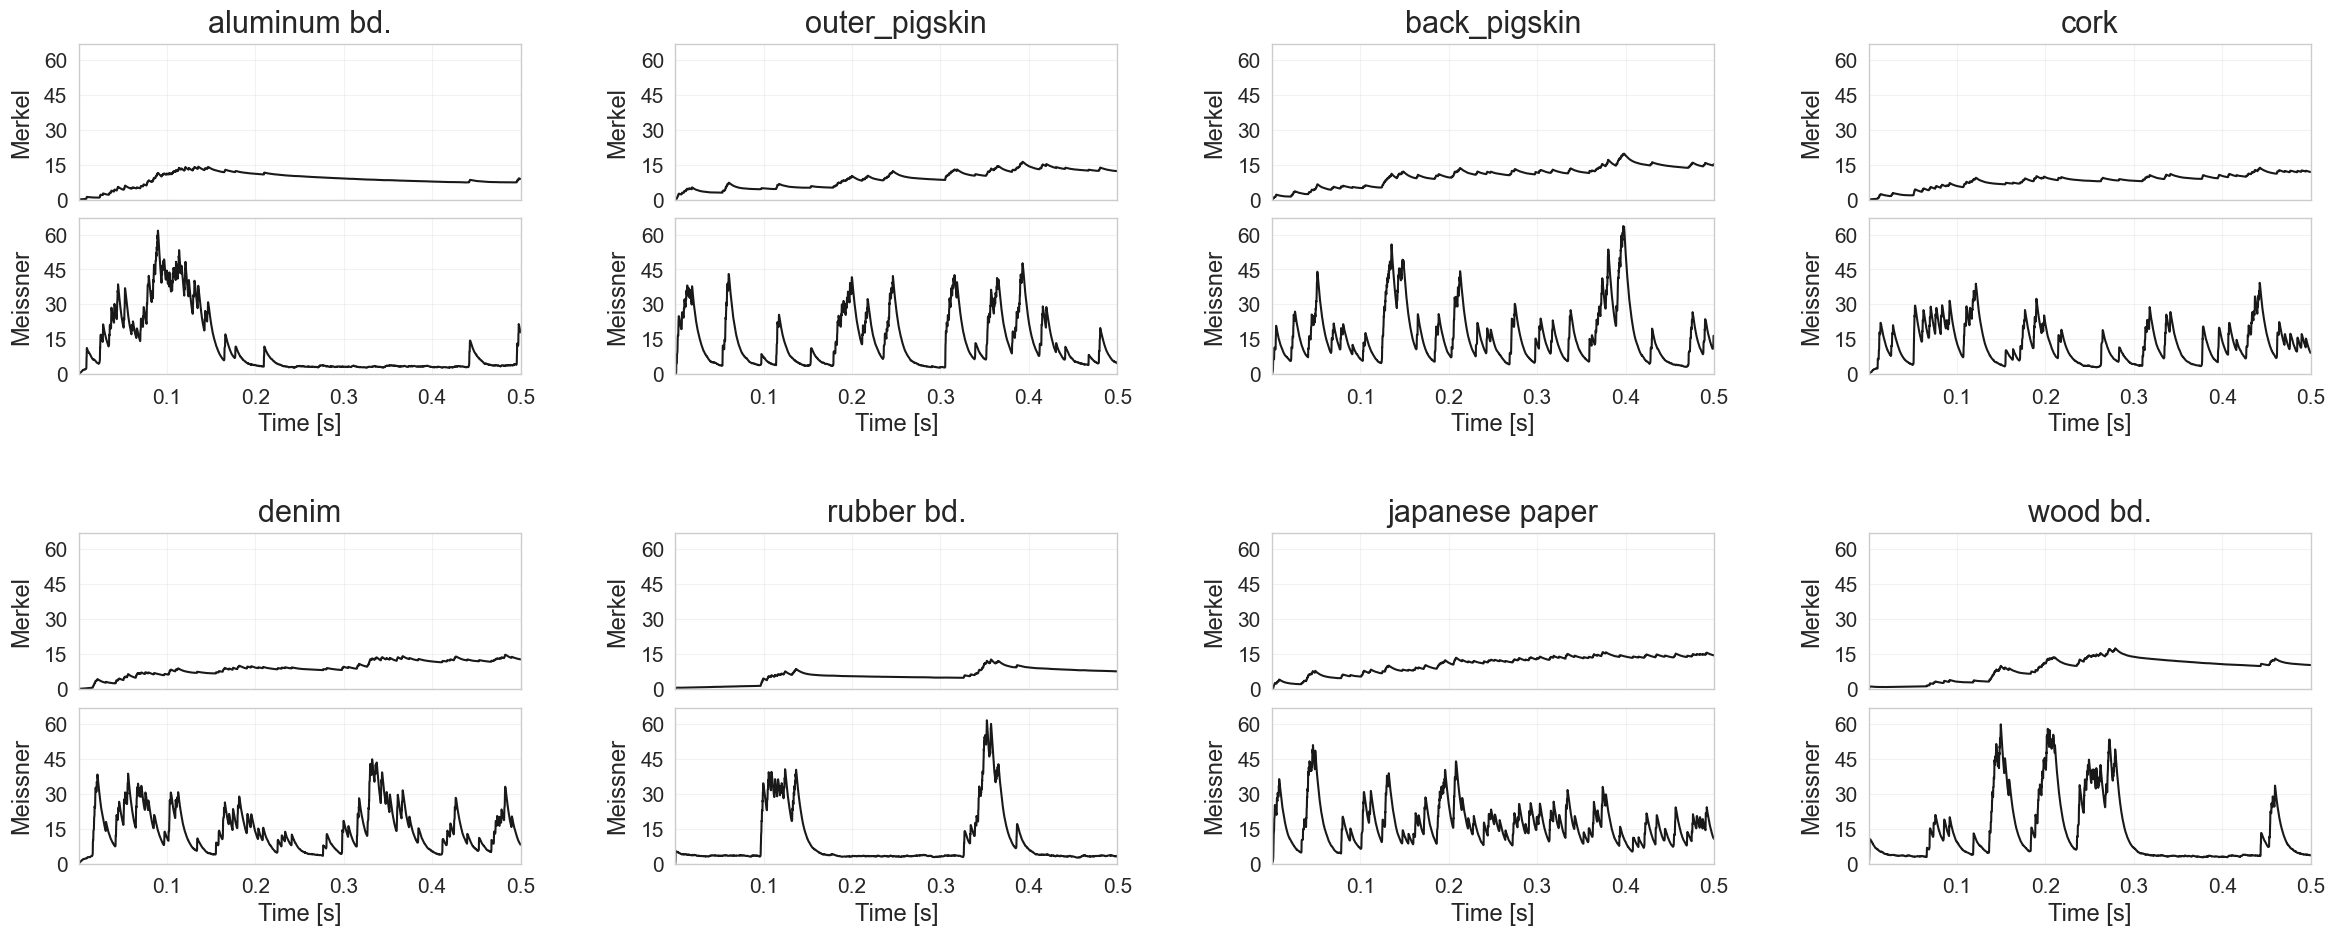

saved: \Users\elast\OneDrive - 学校法人立命館\ドキュメント\研究コード\materials_4x2_blocks_merkel_meissner_final.pdf


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

# =========================================
# フォント設定
# =========================================
rcParams["font.family"] = "Yu Gothic"

# =========================================
# パス設定
# =========================================
BASE_PATH = Path("/Users/elast/OneDrive - 学校法人立命館/ドキュメント/研究コード")
DATA_ROOT = BASE_PATH / "tactile_data"
SAVE_PATH = BASE_PATH / "materials_4x2_blocks_merkel_meissner_final.pdf"

# =========================================
# 材料名
# =========================================
dir_name = [
    "Al_board",
    "buta_omote",
    "buta_ura",
    "cork",
    "denim",
    "rubber_board",
    "washi",
    "wood_board"
]

titles = [
    "aluminum bd.",
    "outer_pigskin",
    "back_pigskin",
    "cork",
    "denim",
    "rubber bd.",
    "japanese paper",
    "wood bd."
]

# =========================================
# パラメータ設定
# =========================================
dt_data = 0.0001
dt = dt_data

start_idx = 3000
end_idx = 8000

n_trials = 1          # 3 にすると各材料で3本重ね描き
channel_index = 0     # 0, 1, 2 のどれか

# スケーリング
merkel_scale = 0.008
meissner_scale = 0.0876

# 見た目
TITLE_FS = 22
LABEL_FS = 17
TICK_FS = 15
LINEWIDTH = 1.5

# 横軸は 0.5 まで固定
XMAX = 0.5
XTICKS = np.arange(0, 0.51, 0.1)

# =========================================
# Meissner 計算
# =========================================
def calc_meissner(data, t, dt):
    I = np.zeros((4, len(t)))

    for i in range(1, len(t)):
        dF_dt = np.abs(data[i] - data[i - 1]) / (t[i] - t[i - 1])

        I[0, i] = I[0, i - 1] + 1.0 * dF_dt + (-I[0, i - 1] * dt / (8 * 1e-3))
        I[1, i] = I[1, i - 1] + 0.24 * dF_dt + (-(I[1, i - 1] - 0.24 * 0.13) * dt / (200 * 1e-3))
        I[2, i] = I[2, i - 1] + 0.07 * dF_dt + (-I[2, i - 1] * dt / (1744.6 * 1e-3))
        I[3, i] = I[0, i]

    return I[3, :]

# =========================================
# Merkel 計算
# =========================================
def calc_merkel(data, t, dt):
    I = np.zeros((4, len(t)))

    for i in range(1, len(t)):
        dF_dt = np.abs(data[i] - data[i - 1]) / (t[i] - t[i - 1])

        I[0, i] = I[0, i - 1] + 0.74 * dF_dt + (-I[0, i - 1] * dt / (8 * 1e-3))
        I[1, i] = I[1, i - 1] + 0.24 * dF_dt + (-(I[1, i - 1] - 0.24 * 0.13) * dt / (200 * 1e-3))
        I[2, i] = I[2, i - 1] + 0.07 * dF_dt + (-I[2, i - 1] * dt / (1744.6 * 1e-3))
        I[3, i] = I[0, i] + I[1, i] + I[2, i]

    return I[3, :]

# =========================================
# ファイル読み込み
# =========================================
def load_trial_file(material_name, trial_index):
    material_dir = DATA_ROOT / material_name
    files = sorted(material_dir.glob(f"data_{trial_index}_*"))

    if not files:
        raise FileNotFoundError(f"No file found: {material_dir}/data_{trial_index}_*")

    return files[0]

# =========================================
# 描画用データ作成
# =========================================
plot_data = []

for i, material in enumerate(dir_name):
    merkel_trials = []
    meissner_trials = []

    for j in range(n_trials):
        file_path = load_trial_file(material, j + 1)
        df = pd.read_table(file_path, header=None)
        df_np = df.to_numpy().T

        # 3チャネル分切り出し
        in_data_0 = df_np[:3, start_idx:end_idx]

        nt = in_data_0.shape[1]
        t_array = np.arange(nt) * dt_data

        # 指定チャネルのみ使用
        in_data = in_data_0[channel_index, :]

        I_merkel = calc_merkel(in_data, t_array, dt)
        I_meissner = calc_meissner(in_data, t_array, dt)

        merkel_trials.append(merkel_scale * I_merkel)
        meissner_trials.append(meissner_scale * I_meissner)

    plot_data.append({
        "title": titles[i],
        "t": t_array,
        "merkel": merkel_trials,
        "meissner": meissner_trials
    })

# =========================================
# 全サブプロット共通の縦軸範囲
# =========================================
all_values = []

for d in plot_data:
    for y in d["merkel"]:
        all_values.append(y)
    for y in d["meissner"]:
        all_values.append(y)

all_values = np.concatenate(all_values)

common_ymax = all_values.max() * 1.05
if common_ymax <= 0:
    common_ymax = 1.0

# 整数目盛りにしたいので上端も整数にそろえる
common_ymax = np.ceil(common_ymax)

# x軸の左端 0.0 は消して、y軸の 0 とかぶりにくくする
xlabels_bottom = ["" if np.isclose(x, 0.0) else f"{x:.1f}" for x in XTICKS]

# =========================================
# 描画
# =========================================
plt.style.use("seaborn-v0_8-whitegrid")

fig = plt.figure(figsize=(24, 10))
outer = GridSpec(
    2, 4,
    figure=fig,
    wspace=0.35,
    hspace=0.48
)

for idx, d in enumerate(plot_data):
    r = idx // 4
    c = idx % 4

    inner = GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer[r, c],
        hspace=0.12
    )

    ax_top = fig.add_subplot(inner[0])
    ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

    # Merkel
    for y in d["merkel"]:
        ax_top.plot(d["t"], y, linewidth=LINEWIDTH, color="black", alpha=0.9)

    # Meissner
    for y in d["meissner"]:
        ax_bottom.plot(d["t"], y, linewidth=LINEWIDTH, color="black", alpha=0.9)

    # タイトル
    ax_top.set_title(d["title"], fontsize=TITLE_FS, pad=8)

    # ラベル
    ax_top.set_ylabel("Merkel", fontsize=LABEL_FS, labelpad=8)
    ax_bottom.set_ylabel("Meissner", fontsize=LABEL_FS, labelpad=8)
    ax_bottom.set_xlabel("Time [s]", fontsize=LABEL_FS, labelpad=4)

    # 目盛り文字サイズと余白
    ax_top.tick_params(axis="x", labelsize=TICK_FS, pad=8)
    ax_top.tick_params(axis="y", labelsize=TICK_FS, pad=8)
    ax_bottom.tick_params(axis="x", labelsize=TICK_FS, pad=10)
    ax_bottom.tick_params(axis="y", labelsize=TICK_FS, pad=8)

    # 上段の x 軸ラベルは消す
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # 横軸
    ax_top.set_xlim(0, XMAX)
    ax_bottom.set_xlim(0, XMAX)

    ax_top.set_xticks(XTICKS)
    ax_bottom.set_xticks(XTICKS)

    ax_top.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax_bottom.set_xticklabels(xlabels_bottom)

    # 縦軸を全グラフで共通にする
    ax_top.set_ylim(0, common_ymax)
    ax_bottom.set_ylim(0, common_ymax)

    # 縦軸は整数目盛り・小数点なし
    ax_top.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax_bottom.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax_top.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax_bottom.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

    # グリッド
    ax_top.grid(True, alpha=0.25)
    ax_bottom.grid(True, alpha=0.25)

# 全体余白
fig.subplots_adjust(left=0.065, right=0.995, top=0.92, bottom=0.10)

# 保存
fig.savefig(SAVE_PATH, bbox_inches="tight")
plt.show()

print(f"saved: {SAVE_PATH}")